# ResNet for Tropical Cyclone Forecasting

Cross-basin generalisation experiment: train on Western Pacific (WP), evaluate zero-shot and fine-tuned transfer to South Pacific (SP).
Uses a torchvision ResNet backbone adapted for 15-channel atmospheric grids (81×81) with late fusion of environmental and 1D features.

## Section 0: Setup & Configuration

In [1]:
import torch.multiprocessing as mp
mp.set_start_method("fork", force=True)


import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as tv_models
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, f1_score, accuracy_score
)
from pathlib import Path
from collections import Counter
from copy import deepcopy
from tqdm.auto import tqdm
import warnings, os

warnings.filterwarnings("ignore")

# ── Paths ──
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "processed"

# ── ResNet hyperparameters ──
RESNET_SIZE     = "resnet152"  # best from Optuna (resnet18/34 searched)
HEAD_DIM        = 128         # best from Optuna
DROPOUT         = 0.2         # best from Optuna
IN_CHANNELS     = 15          # SST + u/v/z at 4 pressure levels + shear + vorticity

# ── Training ──
BATCH_SIZE  = 32   # reduced for ResNet152 VRAM budget
LR          = 1.716e-4   # best from Optuna
WEIGHT_DECAY = 3.041e-4  # best from Optuna
EPOCHS      = 80
PATIENCE    = 15          # early stopping patience
DIR_WEIGHT  = 0.5         # loss = DIR_WEIGHT * L_dir + (1 - DIR_WEIGHT) * L_int
LABEL_SMOOTH = 0.0        # best from Optuna
SCHEDULER   = "cosine"    # best from Optuna
AUG_HFLIP   = False       # best from Optuna
AUG_VFLIP   = True        # best from Optuna

# ── Multimodal fusion ──
USE_ENV = True            # fuse 40-dim environmental features
USE_1D  = True            # fuse 4-dim 1D features (lat, lon, wind, pressure)

# ── Fine-tuning ──
FT_LR       = 5e-5    # lower for ResNet152 to prevent catastrophic forgetting
FT_EPOCHS   = 60     # more epochs with lower LR
FT_PATIENCE = 10

# ── Task ──
N_DIR_CLASSES = 8
N_INT_CLASSES = 4
DIR_LABELS  = ["E", "SE", "S", "SW", "W", "NW", "N", "NE"]
INTE_LABELS = ["Weakening", "Steady", "Slow-intens.", "Rapid-intens."]

# ── Reproducibility ──
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE} ({torch.cuda.get_device_name(0) if DEVICE == 'cuda' else 'CPU'})")
print(f"Data dir: {DATA_DIR}")

Device: cuda (NVIDIA GeForce RTX 5090)
Data dir: /root/climate-change-group-project/data/processed


/root/anaconda3/envs/climate/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Section 1: Data Loading & Dataset

Load the preprocessed `.pt` tensors produced by the shared preprocessing pipeline. Each file is a dict mapping `storm_id → tensor`.

- **grids**: `(N_timesteps, 15, 81, 81)` — 15-channel atmospheric fields (SST + u/v/z at 4 pressure levels + derived)
- **env**: `(N_timesteps, 40)` — environmental features
- **data1d**: `(N_timesteps, 4)` — 1D track features (lat, lon, wind, pressure)
- **labels**: direction (8 classes) + intensity change (4 classes)

In [2]:
# ── Load all splits ──
SPLITS = {
    "wp_train":    {"reflected": False},
    "wp_val":      {"reflected": False},
    "sp_test":     {"reflected": True},
    "sp_ft_train": {"reflected": True},
    "sp_ft_val":   {"reflected": True},
}

raw = {}
for split in SPLITS:
    raw[split] = {
        "grids":  torch.load(DATA_DIR / "grids"  / f"{split}_grids.pt",  weights_only=False),
        "env":    torch.load(DATA_DIR / "env"     / f"{split}_env.pt",    weights_only=False),
        "data1d": torch.load(DATA_DIR / "data1d"  / f"{split}_1d.pt",    weights_only=False),
        "labels": torch.load(DATA_DIR / "labels"  / f"{split}_labels.pt", weights_only=False),
    }

print(f"Loaded {len(SPLITS)} splits")
for split in SPLITS:
    n_storms = len(raw[split]["grids"])
    n_ts = sum(v.shape[0] for v in raw[split]["grids"].values())
    print(f"  {split:15s}: {n_storms:3d} storms, {n_ts:5d} timesteps")

Loaded 5 splits
  wp_train       : 105 storms,  3716 timesteps
  wp_val         :  26 storms,   846 timesteps
  sp_test        :  15 storms,   427 timesteps
  sp_ft_train    :  12 storms,   402 timesteps
  sp_ft_val      :   3 storms,    93 timesteps


In [3]:
class CycloneDataset(Dataset):
    """Flattens storm-level dicts into timestep-level samples.

    Filters out sentinel labels (-1).  Grids are already normalised
    (channel-wise z-score) by the preprocessing pipeline.
    1D features are z-scored using training-set statistics passed at init.
    For SP splits, uses hemisphere-reflected direction labels.
    """
    def __init__(self, grids, env, data1d, labels, use_reflected=False,
                 d1d_mean=None, d1d_std=None):
        self.samples = []
        dir_key = "direction_reflected" if use_reflected else "direction"

        for storm_id in grids:
            g = grids[storm_id]        # (N_t, 15, 81, 81)
            e = env[storm_id]          # (N_t, 40)
            d = data1d[storm_id]       # (N_t, 4)
            d_lbl = labels[storm_id][dir_key]     # (N_t,)
            i_lbl = labels[storm_id]["intensity"]  # (N_t,)

            for t in range(g.shape[0]):
                if d_lbl[t].item() == -1 or i_lbl[t].item() == -1:
                    continue
                self.samples.append((
                    g[t], e[t], d[t],
                    d_lbl[t].long(), i_lbl[t].long(),
                ))

        # Compute or store 1D normalisation stats
        if d1d_mean is None:
            all_1d = torch.stack([s[2] for s in self.samples])
            self.d1d_mean = all_1d.mean(dim=0)
            self.d1d_std  = all_1d.std(dim=0).clamp(min=1e-6)
        else:
            self.d1d_mean = d1d_mean
            self.d1d_std  = d1d_std

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        grid, env, d1d, dir_lbl, int_lbl = self.samples[idx]
        d1d = (d1d - self.d1d_mean) / self.d1d_std
        return grid, env, d1d, dir_lbl, int_lbl

In [4]:
# ── Build datasets and loaders ──
# Build WP train first to get 1D normalisation stats
datasets = {}
datasets["wp_train"] = CycloneDataset(
    raw["wp_train"]["grids"], raw["wp_train"]["env"],
    raw["wp_train"]["data1d"], raw["wp_train"]["labels"],
    use_reflected=False
)
# Reuse WP train 1D stats for all other splits (prevent leakage)
d1d_mean = datasets["wp_train"].d1d_mean
d1d_std  = datasets["wp_train"].d1d_std
print(f"1D norm stats — mean: {d1d_mean.tolist()}, std: {d1d_std.tolist()}")

for split, cfg in SPLITS.items():
    if split == "wp_train":
        continue
    datasets[split] = CycloneDataset(
        raw[split]["grids"], raw[split]["env"], raw[split]["data1d"],
        raw[split]["labels"], use_reflected=cfg["reflected"],
        d1d_mean=d1d_mean, d1d_std=d1d_std
    )

loaders = {}
for split in SPLITS:
    shuffle = "train" in split
    loaders[split] = DataLoader(
        datasets[split], batch_size=BATCH_SIZE, shuffle=shuffle,
        num_workers=1, pin_memory=True, drop_last=False
    )

for split, ds in datasets.items():
    print(f"{split:15s}: {len(ds):5d} valid samples")

# Verify a sample
g, e, d, dl, il = datasets["wp_train"][0]
print(f"\nSample shapes — grid: {g.shape}, env: {e.shape}, 1d: {d.shape}, dir: {dl}, int: {il}")
print(f"Grid stats  — mean: {g.mean():.4f}, std: {g.std():.4f}")
print(f"1D (normed) — {d}")

1D norm stats — mean: [0.25115007162094116, -0.30904674530029297, -5.3783392906188965, 2.2481181621551514], std: [0.41245394945144653, 0.4831640124320984, 5.254057884216309, 2.3741278648376465]
wp_train       :  3252 valid samples
wp_val         :   730 valid samples
sp_test        :   367 valid samples
sp_ft_train    :   354 valid samples
sp_ft_val      :    81 valid samples

Sample shapes — grid: torch.Size([15, 81, 81]), env: torch.Size([40]), 1d: torch.Size([4]), dir: 5, int: 0
Grid stats  — mean: -0.0329, std: 0.6397
1D (normed) — tensor([ 1.4277, -1.5956,  0.6696,  0.3925])


In [5]:
# ── Class weights (inverse frequency from WP train) ──
dir_counts = Counter()
int_counts = Counter()
for _, _, _, dl, il in datasets["wp_train"].samples:
    dir_counts[dl.item()] += 1
    int_counts[il.item()] += 1

n_total = len(datasets["wp_train"])

dir_weights = torch.zeros(N_DIR_CLASSES)
for c in range(N_DIR_CLASSES):
    dir_weights[c] = n_total / (N_DIR_CLASSES * max(dir_counts[c], 1))

int_weights = torch.zeros(N_INT_CLASSES)
for c in range(N_INT_CLASSES):
    int_weights[c] = n_total / (N_INT_CLASSES * max(int_counts[c], 1))

print("Direction class distribution (WP train):")
for c in range(N_DIR_CLASSES):
    print(f"  {DIR_LABELS[c]:4s}: {dir_counts[c]:4d} ({dir_counts[c]/n_total*100:5.1f}%)  weight={dir_weights[c]:.2f}")

print(f"\nIntensity class distribution (WP train):")
for c in range(N_INT_CLASSES):
    print(f"  {INTE_LABELS[c]:14s}: {int_counts[c]:4d} ({int_counts[c]/n_total*100:5.1f}%)  weight={int_weights[c]:.2f}")

Direction class distribution (WP train):
  E   :  218 (  6.7%)  weight=1.86
  SE  :   29 (  0.9%)  weight=14.02
  S   :   18 (  0.6%)  weight=22.58
  SW  :   62 (  1.9%)  weight=6.56
  W   :  917 ( 28.2%)  weight=0.44
  NW  :  993 ( 30.5%)  weight=0.41
  N   :  529 ( 16.3%)  weight=0.77
  NE  :  486 ( 14.9%)  weight=0.84

Intensity class distribution (WP train):
  Weakening     : 1491 ( 45.8%)  weight=0.55
  Steady        :  193 (  5.9%)  weight=4.21
  Slow-intens.  : 1124 ( 34.6%)  weight=0.72
  Rapid-intens. :  444 ( 13.7%)  weight=1.83


## Section 2: ResNet Architecture

We adapt a standard torchvision ResNet backbone for our 15-channel 81×81 atmospheric grids.

Key modifications from the standard ImageNet ResNet:
- **conv1**: 3×3 kernel with stride 1 (instead of 7×7 stride 2) — preserves spatial resolution for our small 81×81 inputs
- **No maxpool** after conv1 — again to avoid aggressive downsampling
- **Spatial progression**: 81 → 81 → 41 → 21 → 11 through the four residual layer groups
- **Late fusion**: after global average pooling, concatenate environmental (40d) and 1D track (4d) features
- **Dual MLP heads**: separate 3-layer heads for direction (8 classes) and intensity (4 classes)

In [6]:
class ResNetClassifier(nn.Module):
    """ResNet backbone for tropical cyclone classification.

    Architecture:
        Modified conv1 (15ch, 3×3, stride 1) → BN → GELU
        → layer1-4 (from torchvision, BasicBlock or Bottleneck)
        → AdaptiveAvgPool2d(1,1) → flatten
        → [optional: concat env + 1D features]
        → MLP direction head (8 classes)
        → MLP intensity head (4 classes)

    Spatial progression (81×81 input):
        conv1: 81→81 (stride 1, no maxpool)
        layer1: 81→81 (stride 1)
        layer2: 81→41 (stride 2)
        layer3: 41→21 (stride 2)
        layer4: 21→11 (stride 2)
        GAP: 11→1
    """
    # Feature dimensions for each ResNet variant
    FEAT_DIMS = {"resnet18": 512, "resnet34": 512, "resnet50": 2048, "resnet152": 2048}

    def __init__(self, resnet_size="resnet18", in_channels=15,
                 n_dir_classes=8, n_int_classes=4,
                 env_dim=40, d1d_dim=4, use_env=True, use_1d=True,
                 head_dim=128, dropout=0.1):
        super().__init__()
        self.use_env = use_env
        self.use_1d  = use_1d
        self.resnet_size = resnet_size

        # ── Get torchvision backbone (no pretrained weights) ──
        backbone_fn = getattr(tv_models, resnet_size)
        backbone = backbone_fn(weights=None)

        # ── Replace conv1: 3×3 stride 1 for small 81×81 inputs ──
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn1 = backbone.bn1
        self.act = nn.GELU()
        # NOTE: we skip backbone.maxpool to preserve spatial resolution

        # ── Copy residual layer groups from torchvision ──
        self.layer1 = backbone.layer1  # 64  → 64  (resnet18/34) or 256  (resnet50)
        self.layer2 = backbone.layer2  # 64  → 128 (resnet18/34) or 512  (resnet50)
        self.layer3 = backbone.layer3  # 128 → 256 (resnet18/34) or 1024 (resnet50)
        self.layer4 = backbone.layer4  # 256 → 512 (resnet18/34) or 2048 (resnet50)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        # ── Classification heads ──
        feat_dim = self.FEAT_DIMS[resnet_size]
        aux_dim = (env_dim if use_env else 0) + (d1d_dim if use_1d else 0)
        head_in = feat_dim + aux_dim

        self.head_dir = nn.Sequential(
            nn.Linear(head_in, head_dim), nn.GELU(),
            nn.Dropout(dropout * 2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_dim // 2, n_dir_classes),
        )
        self.head_int = nn.Sequential(
            nn.Linear(head_in, head_dim), nn.GELU(),
            nn.Dropout(dropout * 2),
            nn.Linear(head_dim, head_dim // 2), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(head_dim // 2, n_int_classes),
        )

    def forward(self, grid, env=None, d1d=None):
        # grid: (B, 15, 81, 81)
        x = self.act(self.bn1(self.conv1(grid)))  # (B, 64, 81, 81)
        # No maxpool — go straight to residual layers
        x = self.layer1(x)  # (B, 64/256, 81, 81)
        x = self.layer2(x)  # (B, 128/512, 41, 41)
        x = self.layer3(x)  # (B, 256/1024, 21, 21)
        x = self.layer4(x)  # (B, 512/2048, 11, 11)
        x = self.gap(x).flatten(1)  # (B, feat_dim)

        # Late fusion of auxiliary features
        parts = [x]
        if self.use_env and env is not None:
            parts.append(env)
        if self.use_1d and d1d is not None:
            parts.append(d1d)
        x = torch.cat(parts, dim=-1)

        return self.head_dir(x), self.head_int(x)

**Note on residual blocks:**
- ResNet18/34 use `BasicBlock` (two 3×3 convs per block, output 512-d features)
- ResNet50 uses `Bottleneck` (1×1 → 3×3 → 1×1 per block, output 2048-d features)

Both include proper residual (skip) connections with downsampling projections where needed. These are inherited directly from torchvision — no custom implementation required.

In [7]:
# ── Instantiate and inspect ──
model = ResNetClassifier(
    resnet_size=RESNET_SIZE, in_channels=IN_CHANNELS,
    n_dir_classes=N_DIR_CLASSES, n_int_classes=N_INT_CLASSES,
    env_dim=40, d1d_dim=4, use_env=USE_ENV, use_1d=USE_1D,
    head_dim=HEAD_DIM, dropout=DROPOUT,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
n_train  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {n_params:,}")
print(f"Trainable parameters: {n_train:,}")
print(f"Samples/params ratio: {len(datasets['wp_train'])/n_params:.2f}")

# Smoke test
with torch.no_grad():
    dummy_g = torch.randn(2, 15, 81, 81, device=DEVICE)
    dummy_e = torch.randn(2, 40, device=DEVICE)
    dummy_d = torch.randn(2, 4,  device=DEVICE)
    d_out, i_out = model(dummy_g, dummy_e, dummy_d)
    print(f"Direction logits: {d_out.shape}  Intensity logits: {i_out.shape}")
    print(f"Logit range: [{d_out.min():.3f}, {d_out.max():.3f}] (should NOT be ~0)")

Total parameters:     58,696,140
Trainable parameters: 58,696,140
Samples/params ratio: 0.00
Direction logits: torch.Size([2, 8])  Intensity logits: torch.Size([2, 4])
Logit range: [-0.138, 0.121] (should NOT be ~0)


## Section 2b: Hyperparameter Optimisation (Optuna)

In [8]:
# ── Optuna search SKIPPED for ResNet152 ──
# ResNet152 is too large for iterative Optuna search.
# Using hyperparameters transferred from ResNet18 Optuna + manual tuning.
print('Optuna search skipped — using hardcoded hyperparameters (see next cell)')


Optuna search skipped — using hardcoded hyperparameters (see next cell)


In [9]:
# Optuna visualization skipped (no search was run)
print('Skipped — no Optuna search to visualize')


Skipped — no Optuna search to visualize


In [10]:
# ── Hardcoded hyperparameters for ResNet152 (iteration 7) ──
# WP training: same as iter2 (best WP=0.512)
# Fine-tuning: two-phase with combined score checkpointing
RESNET_SIZE     = "resnet152"
LR              = 5e-4
WEIGHT_DECAY    = 1e-3
DIR_WEIGHT      = 0.5
BEST_DROPOUT    = 0.25
BEST_LABEL_SMOOTH = 0.05
BEST_HEAD_DIM   = 128
BEST_SCHEDULER  = "onecycle"
BEST_AUG_HFLIP  = False
BEST_AUG_VFLIP  = True

# Fine-tuning
FT_LR       = 5e-5     # lower LR like iter2 (best intensity transfer)
FT_EPOCHS   = 80
FT_PATIENCE = 15

print("Hyperparameters for ResNet152 (iteration 7):")
print(f"  Architecture : {RESNET_SIZE}, head={BEST_HEAD_DIM}")
print(f"  Optimiser    : AdamW, lr={LR:.5f}, wd={WEIGHT_DECAY:.5f}")
print(f"  Scheduler    : {BEST_SCHEDULER}")
print(f"  Regularisation: dropout={BEST_DROPOUT}, "
      f"label_smooth={BEST_LABEL_SMOOTH}, dir_weight={DIR_WEIGHT}")
print(f"  Augmentation : hflip={BEST_AUG_HFLIP}, vflip={BEST_AUG_VFLIP}")
print(f"  Fine-tune LR : {FT_LR}, epochs={FT_EPOCHS}, patience={FT_PATIENCE}")

# ── Rebuild model with best params ──
torch.manual_seed(SEED)
model = ResNetClassifier(
    resnet_size=RESNET_SIZE, in_channels=IN_CHANNELS,
    n_dir_classes=N_DIR_CLASSES, n_int_classes=N_INT_CLASSES,
    env_dim=40, d1d_dim=4, use_env=USE_ENV, use_1d=USE_1D,
    head_dim=BEST_HEAD_DIM, dropout=BEST_DROPOUT,
).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nModel parameters: {n_params:,}")


Hyperparameters for ResNet152 (iteration 7):
  Architecture : resnet152, head=128
  Optimiser    : AdamW, lr=0.00050, wd=0.00100
  Scheduler    : onecycle
  Regularisation: dropout=0.25, label_smooth=0.05, dir_weight=0.5
  Augmentation : hflip=False, vflip=True
  Fine-tune LR : 5e-05, epochs=80, patience=15



Model parameters: 58,696,140


## Section 3: Training on WP (with Optuna-tuned hyperparameters)

In [11]:
# ── Loss functions (with label smoothing from Optuna) ──
loss_dir_fn = nn.CrossEntropyLoss(weight=dir_weights.to(DEVICE),
                                   label_smoothing=BEST_LABEL_SMOOTH)
loss_int_fn = nn.CrossEntropyLoss(weight=int_weights.to(DEVICE),
                                   label_smoothing=BEST_LABEL_SMOOTH)

# ── Optimizer (always AdamW for ResNet) ──
optimizer = torch.optim.AdamW(model.parameters(), lr=LR,
                              weight_decay=WEIGHT_DECAY)
print(f"Optimizer: AdamW (lr={LR:.5f}, wd={WEIGHT_DECAY:.5f})")

# ── Scheduler ──
if BEST_SCHEDULER == "onecycle":
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=LR * 3, epochs=EPOCHS,
        steps_per_epoch=len(loaders["wp_train"]))
    STEP_PER_BATCH = True
    print(f"Scheduler: OneCycleLR (max_lr={LR*3:.5f})")
else:
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=1e-6)
    STEP_PER_BATCH = False
    print(f"Scheduler: CosineAnnealing (T_max={EPOCHS})")

Optimizer: AdamW (lr=0.00050, wd=0.00100)
Scheduler: OneCycleLR (max_lr=0.00150)


In [12]:
def train_one_epoch(model, loader, optimizer, device, scheduler=None,
                    step_per_batch=False, aug_hflip=False, aug_vflip=False):
    model.train()
    total_loss = 0.0
    correct_dir = correct_int = total = 0

    for grid, env, d1d, dir_lbl, int_lbl in loader:
        grid    = grid.to(device)
        env     = env.to(device)
        d1d     = d1d.to(device)
        dir_lbl = dir_lbl.to(device)
        int_lbl = int_lbl.to(device)

        # ── Data augmentation (random flips) ──
        if aug_hflip and torch.rand(1).item() > 0.5:
            grid = grid.flip(-1)   # horizontal flip
        if aug_vflip and torch.rand(1).item() > 0.5:
            grid = grid.flip(-2)   # vertical flip

        dir_logits, int_logits = model(grid, env, d1d)
        l_dir = loss_dir_fn(dir_logits, dir_lbl)
        l_int = loss_int_fn(int_logits, int_lbl)
        loss  = DIR_WEIGHT * l_dir + (1 - DIR_WEIGHT) * l_int

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        if step_per_batch and scheduler is not None:
            scheduler.step()

        bs = grid.size(0)
        total_loss  += loss.item() * bs
        correct_dir += (dir_logits.argmax(1) == dir_lbl).sum().item()
        correct_int += (int_logits.argmax(1) == int_lbl).sum().item()
        total       += bs

    return total_loss / total, correct_dir / total, correct_int / total


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    all_dir_pred, all_dir_true = [], []
    all_int_pred, all_int_true = [], []
    total = 0

    for grid, env, d1d, dir_lbl, int_lbl in loader:
        grid    = grid.to(device)
        env     = env.to(device)
        d1d     = d1d.to(device)
        dir_lbl = dir_lbl.to(device)
        int_lbl = int_lbl.to(device)

        dir_logits, int_logits = model(grid, env, d1d)
        l_dir = loss_dir_fn(dir_logits, dir_lbl)
        l_int = loss_int_fn(int_logits, int_lbl)
        loss  = DIR_WEIGHT * l_dir + (1 - DIR_WEIGHT) * l_int

        bs = grid.size(0)
        total_loss += loss.item() * bs
        total      += bs

        all_dir_pred.extend(dir_logits.argmax(1).cpu().tolist())
        all_dir_true.extend(dir_lbl.cpu().tolist())
        all_int_pred.extend(int_logits.argmax(1).cpu().tolist())
        all_int_true.extend(int_lbl.cpu().tolist())

    metrics = {
        "loss":    total_loss / total,
        "dir_acc": accuracy_score(all_dir_true, all_dir_pred),
        "int_acc": accuracy_score(all_int_true, all_int_pred),
        "dir_f1":  f1_score(all_dir_true, all_dir_pred, average="macro",
                            zero_division=0),
        "int_f1":  f1_score(all_int_true, all_int_pred, average="macro",
                            zero_division=0),
        "dir_pred": all_dir_pred, "dir_true": all_dir_true,
        "int_pred": all_int_pred, "int_true": all_int_true,
    }
    return metrics

In [13]:
# ── Training loop with early stopping ──
history = {"train_loss": [], "val_loss": [],
           "train_dir_acc": [], "val_dir_acc": [],
           "train_int_acc": [], "val_int_acc": []}

best_val_loss = float("inf")
best_model_state = None
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_dir_acc, train_int_acc = train_one_epoch(
        model, loaders["wp_train"], optimizer, DEVICE,
        scheduler=scheduler if STEP_PER_BATCH else None,
        step_per_batch=STEP_PER_BATCH,
        aug_hflip=BEST_AUG_HFLIP, aug_vflip=BEST_AUG_VFLIP)

    val_metrics = evaluate(model, loaders["wp_val"], DEVICE)

    if not STEP_PER_BATCH:
        scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["train_dir_acc"].append(train_dir_acc)
    history["val_dir_acc"].append(val_metrics["dir_acc"])
    history["train_int_acc"].append(train_int_acc)
    history["val_int_acc"].append(val_metrics["int_acc"])

    # Early stopping
    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_model_state = deepcopy(model.state_dict())
        patience_counter = 0
        marker = " ★"
    else:
        patience_counter += 1
        marker = ""

    if epoch % 5 == 0 or epoch == 1 or marker:
        print(f"Epoch {epoch:3d}/{EPOCHS} │ "
              f"Train loss={train_loss:.4f} dir={train_dir_acc:.3f} int={train_int_acc:.3f} │ "
              f"Val loss={val_metrics['loss']:.4f} dir={val_metrics['dir_acc']:.3f} "
              f"int={val_metrics['int_acc']:.3f}{marker}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch} (patience={PATIENCE})")
        break

# Restore best model
model.load_state_dict(best_model_state)
print(f"\nBest val loss: {best_val_loss:.4f}")
print(f"Best val dir acc: {max(history['val_dir_acc']):.4f}")

Epoch   1/80 │ Train loss=2.0152 dir=0.083 int=0.435 │ Val loss=1.9699 dir=0.055 int=0.507 ★


Epoch   2/80 │ Train loss=1.9714 dir=0.177 int=0.453 │ Val loss=1.9697 dir=0.249 int=0.553 ★


Epoch   3/80 │ Train loss=1.9500 dir=0.224 int=0.454 │ Val loss=1.9412 dir=0.144 int=0.529 ★


Epoch   4/80 │ Train loss=1.9202 dir=0.185 int=0.445 │ Val loss=1.9161 dir=0.258 int=0.547 ★


Epoch   5/80 │ Train loss=1.8825 dir=0.229 int=0.482 │ Val loss=1.9098 dir=0.258 int=0.463 ★


...

Epoch  16/80 │ Train loss=1.6806 dir=0.445 int=0.586 │ Val loss=1.6839 dir=0.512 int=0.549 ★


Epoch  20/80 │ Train loss=1.6249 dir=0.500 int=0.594 │ Val loss=1.7212 dir=0.389 int=0.526


Epoch  25/80 │ Train loss=1.5500 dir=0.528 int=0.617 │ Val loss=1.6983 dir=0.436 int=0.567


Epoch  30/80 │ Train loss=1.4828 dir=0.550 int=0.633 │ Val loss=1.7167 dir=0.474 int=0.582



Early stopping at epoch 31 (patience=15)

Best val loss: 1.6839
Best val dir acc: 0.5123


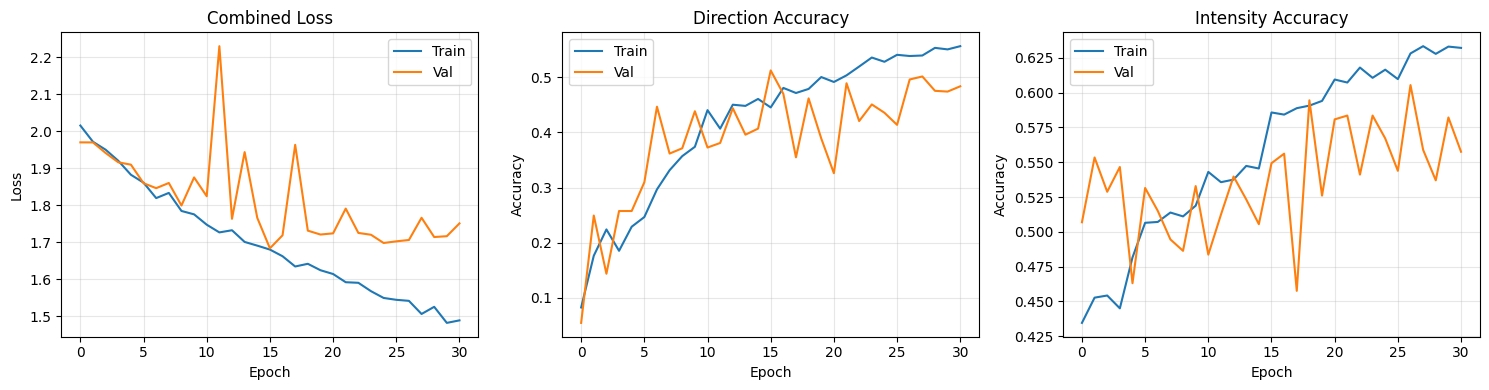

In [14]:
# ── Learning curves ──
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], label="Train")
axes[0].plot(history["val_loss"],   label="Val")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Combined Loss"); axes[0].legend()

axes[1].plot(history["train_dir_acc"], label="Train")
axes[1].plot(history["val_dir_acc"],   label="Val")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Direction Accuracy"); axes[1].legend()

axes[2].plot(history["train_int_acc"], label="Train")
axes[2].plot(history["val_int_acc"],   label="Val")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Accuracy")
axes[2].set_title("Intensity Accuracy"); axes[2].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "resnet_learning_curves.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Section 4: WP In-Basin Evaluation

In [15]:
def plot_confusion_matrices(metrics, title_prefix, labels_dir=DIR_LABELS,
                            labels_int=INTE_LABELS):
    """Plot direction and intensity confusion matrices side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    cm_dir = confusion_matrix(metrics["dir_true"], metrics["dir_pred"],
                              labels=list(range(len(labels_dir))))
    cm_int = confusion_matrix(metrics["int_true"], metrics["int_pred"],
                              labels=list(range(len(labels_int))))
    
    sns.heatmap(cm_dir, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_dir, yticklabels=labels_dir, ax=axes[0])
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    axes[0].set_title(f"{title_prefix} — Direction")
    
    sns.heatmap(cm_int, annot=True, fmt="d", cmap="Oranges",
                xticklabels=labels_int, yticklabels=labels_int, ax=axes[1])
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    axes[1].set_title(f"{title_prefix} — Intensity")
    
    plt.tight_layout()
    return fig


def print_metrics(metrics, split_name):
    """Print accuracy and F1 summary."""
    print(f"\n{'='*50}")
    print(f" {split_name}")
    print(f"{'='*50}")
    print(f"  Direction — Acc: {metrics['dir_acc']:.3f}  "
          f"F1 (macro): {metrics['dir_f1']:.3f}")
    print(f"  Intensity — Acc: {metrics['int_acc']:.3f}  "
          f"F1 (macro): {metrics['int_f1']:.3f}")

In [16]:
# ── Evaluate on WP validation ──
wp_val_metrics = evaluate(model, loaders["wp_val"], DEVICE)
print_metrics(wp_val_metrics, "WP Validation (in-basin)")

print("\nDirection classification report:")
print(classification_report(wp_val_metrics["dir_true"],
                            wp_val_metrics["dir_pred"],
                            target_names=DIR_LABELS, zero_division=0))

print("Intensity classification report:")
print(classification_report(wp_val_metrics["int_true"],
                            wp_val_metrics["int_pred"],
                            target_names=INTE_LABELS, zero_division=0))


 WP Validation (in-basin)
  Direction — Acc: 0.512  F1 (macro): 0.404
  Intensity — Acc: 0.549  F1 (macro): 0.463

Direction classification report:
              precision    recall  f1-score   support

           E       0.42      0.43      0.43        23
          SE       0.00      0.00      0.00         7
           S       0.12      0.53      0.20        15
          SW       0.23      0.40      0.29        42
           W       0.76      0.49      0.60       209
          NW       0.65      0.47      0.55       205
           N       0.45      0.59      0.51       127
          NE       0.68      0.63      0.65       102

    accuracy                           0.51       730
   macro avg       0.41      0.44      0.40       730
weighted avg       0.60      0.51      0.54       730

Intensity classification report:
               precision    recall  f1-score   support

    Weakening       0.85      0.58      0.69       346
       Steady       0.13      0.70      0.21        40
 

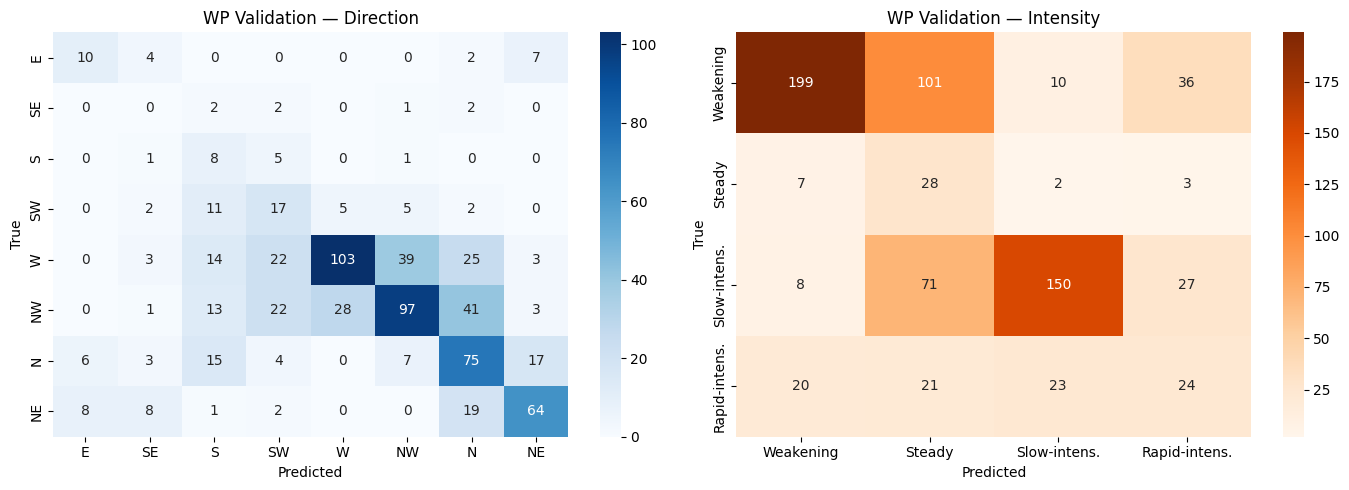

In [17]:
fig = plot_confusion_matrices(wp_val_metrics, "WP Validation")
fig.savefig(PROJECT_ROOT / "figures" / "resnet_wp_val_confusion.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Section 5: Zero-Shot Transfer to South Pacific

The model trained on WP is evaluated directly on SP without any adaptation. SP labels use `direction_reflected` to account for the Coriolis hemisphere mirror — e.g., a WP storm heading NW (class 5) corresponds to a reflected SP storm heading SW (class 3). This mapping was applied during preprocessing.

In [18]:
# ── Zero-shot evaluation on SP test ──
sp_zs_metrics = evaluate(model, loaders["sp_test"], DEVICE)
print_metrics(sp_zs_metrics, "SP Test (zero-shot transfer)")

print("\nDirection classification report:")
print(classification_report(sp_zs_metrics["dir_true"],
                            sp_zs_metrics["dir_pred"],
                            target_names=DIR_LABELS, zero_division=0))

print("Intensity classification report:")
print(classification_report(sp_zs_metrics["int_true"],
                            sp_zs_metrics["int_pred"],
                            target_names=INTE_LABELS, zero_division=0))


 SP Test (zero-shot transfer)
  Direction — Acc: 0.272  F1 (macro): 0.212
  Intensity — Acc: 0.384  F1 (macro): 0.319

Direction classification report:
              precision    recall  f1-score   support

           E       0.50      0.36      0.42        56
          SE       0.00      0.00      0.00         2
           S       0.02      0.14      0.04         7
          SW       0.05      0.25      0.09        12
           W       0.84      0.23      0.36        91
          NW       0.00      0.00      0.00        59
           N       0.43      0.38      0.40        69
          NE       0.37      0.41      0.39        71

    accuracy                           0.27       367
   macro avg       0.28      0.22      0.21       367
weighted avg       0.44      0.27      0.31       367

Intensity classification report:
               precision    recall  f1-score   support

    Weakening       0.62      0.51      0.56       164
       Steady       0.29      0.10      0.14        

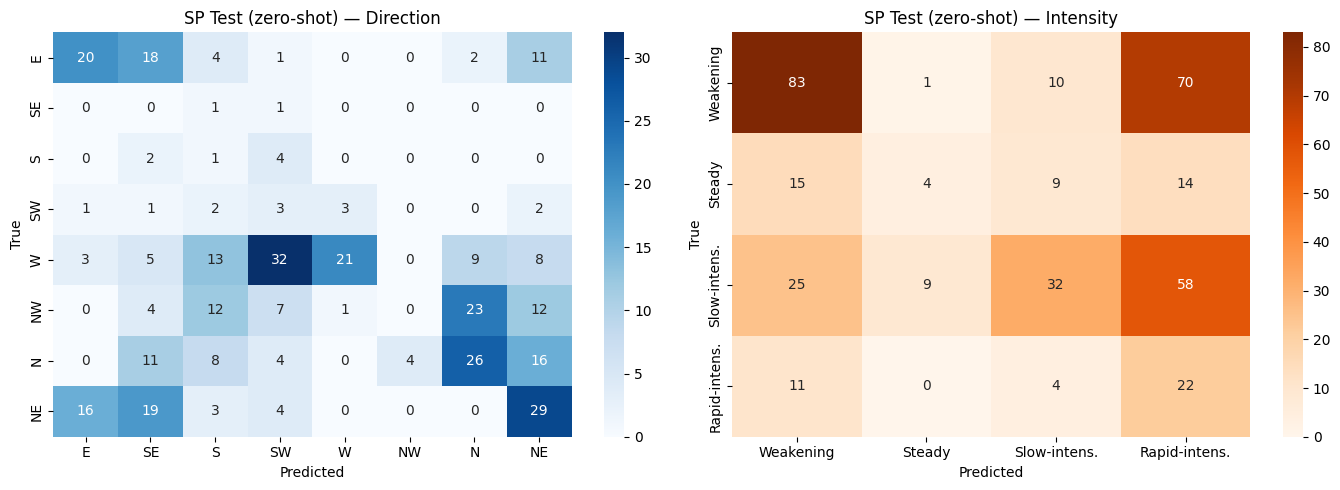

In [19]:
fig = plot_confusion_matrices(sp_zs_metrics, "SP Test (zero-shot)")
fig.savefig(PROJECT_ROOT / "figures" / "resnet_sp_zeroshot_confusion.png", dpi=150,
            bbox_inches="tight")
plt.show()

In [20]:
# ── Transfer gap analysis ──
print("\n" + "=" * 65)
print(" Transfer Gap: WP Val vs SP Zero-Shot")
print("=" * 65)
print(f"{'Metric':<20s} {'WP Val':>10s} {'SP Zero-Shot':>12s} {'Gap':>10s}")
print("-" * 55)
for metric, label in [("dir_acc", "Dir Accuracy"),
                       ("dir_f1",  "Dir F1 (macro)"),
                       ("int_acc", "Int Accuracy"),
                       ("int_f1",  "Int F1 (macro)")]:
    wp = wp_val_metrics[metric]
    sp = sp_zs_metrics[metric]
    gap = sp - wp
    print(f"{label:<20s} {wp:>10.3f} {sp:>12.3f} {gap:>+10.3f}")


 Transfer Gap: WP Val vs SP Zero-Shot
Metric                   WP Val SP Zero-Shot        Gap
-------------------------------------------------------
Dir Accuracy              0.512        0.272     -0.240
Dir F1 (macro)            0.404        0.212     -0.191
Int Accuracy              0.549        0.384     -0.165
Int F1 (macro)            0.463        0.319     -0.144


## Section 6: Fine-Tuning on SP

In [21]:
def finetune(model_state, loaders_ft_train, loaders_ft_val,
             freeze_backbone=False, partial_layers=None,
             lr=FT_LR, epochs=FT_EPOCHS, patience=FT_PATIENCE):
    """Fine-tune selecting checkpoint by best (dir_acc + int_acc)."""
    ft_model = ResNetClassifier(
        resnet_size=RESNET_SIZE, in_channels=IN_CHANNELS,
        n_dir_classes=N_DIR_CLASSES, n_int_classes=N_INT_CLASSES,
        env_dim=40, d1d_dim=4, use_env=USE_ENV, use_1d=USE_1D,
        head_dim=BEST_HEAD_DIM, dropout=BEST_DROPOUT,
    ).to(DEVICE)
    ft_model.load_state_dict(model_state)

    if freeze_backbone:
        for name, p in ft_model.named_parameters():
            if "head" not in name:
                p.requires_grad = False
        trainable = [p for p in ft_model.parameters() if p.requires_grad]
        ft_optimizer = torch.optim.AdamW(trainable, lr=lr, weight_decay=WEIGHT_DECAY)
        print(f"Head-only: {sum(p.numel() for p in trainable):,} trainable params")
    else:
        backbone_params, head_params = [], []
        for name, p in ft_model.named_parameters():
            (head_params if "head" in name else backbone_params).append(p)
        ft_optimizer = torch.optim.AdamW([
            {"params": backbone_params, "lr": lr / 10},
            {"params": head_params, "lr": lr},
        ], weight_decay=WEIGHT_DECAY)
        print(f"Full fine-tune: backbone={lr/10:.6f}, heads={lr:.6f}")

    ft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        ft_optimizer, T_max=epochs, eta_min=1e-6)

    best_score = -1.0
    best_state = deepcopy(ft_model.state_dict())
    wait = 0
    ft_history = {"train_loss": [], "val_loss": [],
                  "val_dir_acc": [], "val_int_acc": []}

    for epoch in range(1, epochs + 1):
        t_loss, _, _ = train_one_epoch(ft_model, loaders_ft_train,
                                        ft_optimizer, DEVICE)
        v = evaluate(ft_model, loaders_ft_val, DEVICE)
        ft_scheduler.step()

        ft_history["train_loss"].append(t_loss)
        ft_history["val_loss"].append(v["loss"])
        ft_history["val_dir_acc"].append(v["dir_acc"])
        ft_history["val_int_acc"].append(v["int_acc"])

        score = v["dir_acc"] + v["int_acc"]  # combined metric
        if score > best_score:
            best_score = score
            best_state = deepcopy(ft_model.state_dict())
            wait = 0
        else:
            wait += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f"  FT Epoch {epoch:3d} │ train_loss={t_loss:.4f} "
                  f"val_loss={v['loss']:.4f} dir={v['dir_acc']:.3f} "
                  f"int={v['int_acc']:.3f} score={score:.3f}")

        if wait >= patience:
            print(f"  Early stopping at epoch {epoch} (best score={best_score:.3f})")
            break

    ft_model.load_state_dict(best_state)
    return ft_model, ft_history


def two_phase_finetune(model_state, loaders_ft_train, loaders_ft_val,
                       phase1_epochs=25, phase2_epochs=40,
                       lr=FT_LR, patience=FT_PATIENCE):
    """Two-phase fine-tuning, checkpoint by combined dir+int accuracy."""
    ft_model = ResNetClassifier(
        resnet_size=RESNET_SIZE, in_channels=IN_CHANNELS,
        n_dir_classes=N_DIR_CLASSES, n_int_classes=N_INT_CLASSES,
        env_dim=40, d1d_dim=4, use_env=USE_ENV, use_1d=USE_1D,
        head_dim=BEST_HEAD_DIM, dropout=BEST_DROPOUT,
    ).to(DEVICE)
    ft_model.load_state_dict(model_state)

    ft_history = {"train_loss": [], "val_loss": [],
                  "val_dir_acc": [], "val_int_acc": []}
    best_score = -1.0
    best_state = deepcopy(ft_model.state_dict())

    # Phase 1: Head-only warmup
    print("Phase 1: Head-only warmup")
    for name, p in ft_model.named_parameters():
        p.requires_grad = "head" in name
    trainable = [p for p in ft_model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(trainable, lr=lr * 3, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=phase1_epochs, eta_min=1e-6)
    print(f"  Trainable: {sum(p.numel() for p in trainable):,} params, lr={lr*3:.6f}")

    for epoch in range(1, phase1_epochs + 1):
        t_loss, _, _ = train_one_epoch(ft_model, loaders_ft_train, optimizer, DEVICE)
        v = evaluate(ft_model, loaders_ft_val, DEVICE)
        sched.step()
        ft_history["train_loss"].append(t_loss)
        ft_history["val_loss"].append(v["loss"])
        ft_history["val_dir_acc"].append(v["dir_acc"])
        ft_history["val_int_acc"].append(v["int_acc"])
        score = v["dir_acc"] + v["int_acc"]
        if score > best_score:
            best_score = score
            best_state = deepcopy(ft_model.state_dict())
        if epoch % 5 == 0 or epoch == 1:
            print(f"  P1 Epoch {epoch:3d} │ train_loss={t_loss:.4f} "
                  f"val_loss={v['loss']:.4f} dir={v['dir_acc']:.3f} "
                  f"int={v['int_acc']:.3f} score={score:.3f}")

    ft_model.load_state_dict(best_state)
    print(f"  Best P1 combined score: {best_score:.3f}")

    # Phase 2: Unfreeze layer4+heads
    print("\nPhase 2: Unfreeze layer4 + heads")
    for name, p in ft_model.named_parameters():
        p.requires_grad = ("head" in name or "layer4" in name)
    backbone_unfrozen = [p for n, p in ft_model.named_parameters()
                        if p.requires_grad and "head" not in n]
    head_params = [p for n, p in ft_model.named_parameters()
                  if p.requires_grad and "head" in n]
    n_trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
    optimizer = torch.optim.AdamW([
        {"params": backbone_unfrozen, "lr": lr / 20},
        {"params": head_params, "lr": lr / 2},
    ], weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=phase2_epochs, eta_min=1e-6)
    print(f"  Trainable: {n_trainable:,} params")

    wait = 0
    for epoch in range(1, phase2_epochs + 1):
        t_loss, _, _ = train_one_epoch(ft_model, loaders_ft_train, optimizer, DEVICE)
        v = evaluate(ft_model, loaders_ft_val, DEVICE)
        sched.step()
        ft_history["train_loss"].append(t_loss)
        ft_history["val_loss"].append(v["loss"])
        ft_history["val_dir_acc"].append(v["dir_acc"])
        ft_history["val_int_acc"].append(v["int_acc"])
        score = v["dir_acc"] + v["int_acc"]
        if score > best_score:
            best_score = score
            best_state = deepcopy(ft_model.state_dict())
            wait = 0
        else:
            wait += 1
        if epoch % 5 == 0 or epoch == 1:
            print(f"  P2 Epoch {epoch:3d} │ train_loss={t_loss:.4f} "
                  f"val_loss={v['loss']:.4f} dir={v['dir_acc']:.3f} "
                  f"int={v['int_acc']:.3f} score={score:.3f}")
        if wait >= patience:
            print(f"  Early stopping at epoch {epoch} (best score={best_score:.3f})")
            break

    ft_model.load_state_dict(best_state)
    return ft_model, ft_history


In [22]:
# ── Strategy 1: Two-phase fine-tuning ──
import gc
model.cpu()
del model
gc.collect()
torch.cuda.empty_cache()

print("Strategy 1: Two-Phase Fine-Tuning")
print("-" * 50)
ft_twophase_model, ft_twophase_hist = two_phase_finetune(
    best_model_state, loaders["sp_ft_train"], loaders["sp_ft_val"],
    phase1_epochs=20, phase2_epochs=60, lr=FT_LR
)
ft_twophase_metrics = evaluate(ft_twophase_model, loaders["sp_ft_val"], DEVICE)
print_metrics(ft_twophase_metrics, "SP Fine-Tuned (two-phase) — Val")


Strategy 1: Two-Phase Fine-Tuning
--------------------------------------------------


Phase 1: Head-only warmup
  Trainable: 553,100 params, lr=0.000150


  P1 Epoch   1 │ train_loss=1.9142 val_loss=1.8376 dir=0.198 int=0.556 score=0.753


  P1 Epoch   5 │ train_loss=1.7178 val_loss=1.6382 dir=0.346 int=0.654 score=1.000


  P1 Epoch  10 │ train_loss=1.6605 val_loss=1.6113 dir=0.358 int=0.556 score=0.914


...

  P2 Epoch   1 │ train_loss=1.7167 val_loss=1.6381 dir=0.296 int=0.654 score=0.951


  P2 Epoch   5 │ train_loss=1.7019 val_loss=1.6416 dir=0.296 int=0.642 score=0.938


  P2 Epoch  10 │ train_loss=1.6599 val_loss=1.6188 dir=0.358 int=0.617 score=0.975


  P2 Epoch  15 │ train_loss=1.6538 val_loss=1.6106 dir=0.370 int=0.568 score=0.938
  Early stopping at epoch 15 (best score=1.000)



 SP Fine-Tuned (two-phase) — Val
  Direction — Acc: 0.346  F1 (macro): 0.169
  Intensity — Acc: 0.654  F1 (macro): 0.498


In [23]:
# ── Strategy 2: Head-only fine-tune ──
ft_twophase_model.cpu()
ft_twophase_state = deepcopy(ft_twophase_model.state_dict())
del ft_twophase_model
gc.collect()
torch.cuda.empty_cache()

print("Strategy 2: Head-Only Fine-Tuning")
print("-" * 40)
ft_head_model, ft_head_hist = finetune(
    best_model_state, loaders["sp_ft_train"], loaders["sp_ft_val"],
    freeze_backbone=True, lr=FT_LR * 2  # higher LR for head-only
)
ft_head_metrics = evaluate(ft_head_model, loaders["sp_ft_val"], DEVICE)
print_metrics(ft_head_metrics, "SP Fine-Tuned (head-only) — Val")


Strategy 2: Head-Only Fine-Tuning
----------------------------------------


Head-only: 553,100 trainable params


  FT Epoch   1 │ train_loss=1.9240 val_loss=1.8660 dir=0.198 int=0.543 score=0.741


  FT Epoch  10 │ train_loss=1.6934 val_loss=1.6338 dir=0.333 int=0.642 score=0.975


  FT Epoch  20 │ train_loss=1.6173 val_loss=1.5842 dir=0.358 int=0.568 score=0.926


  Early stopping at epoch 25 (best score=0.975)



 SP Fine-Tuned (head-only) — Val
  Direction — Acc: 0.333  F1 (macro): 0.168
  Intensity — Acc: 0.642  F1 (macro): 0.517


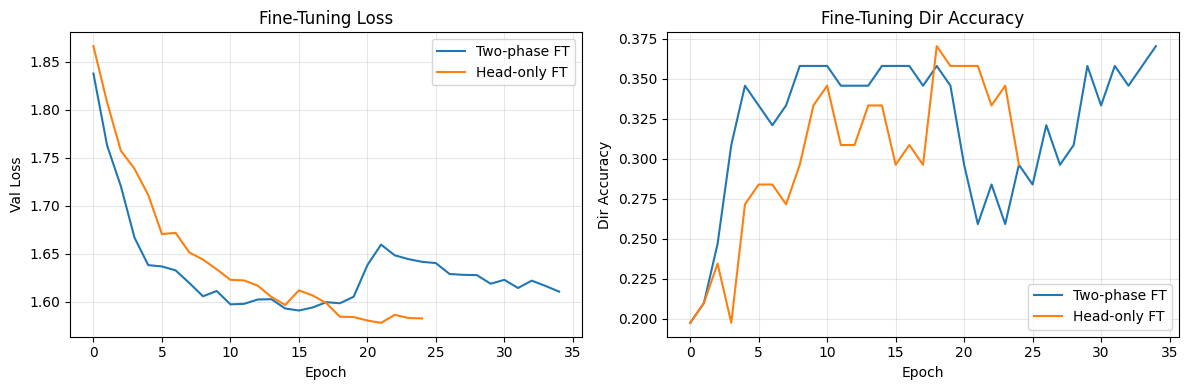

In [24]:
# ── Fine-tuning learning curves ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for hist, label in [(ft_twophase_hist, "Two-phase FT"),
                     (ft_head_hist, "Head-only FT")]:
    axes[0].plot(hist["val_loss"], label=label)
    axes[1].plot(hist["val_dir_acc"], label=label)

axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Val Loss")
axes[0].set_title("Fine-Tuning Loss"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Dir Accuracy")
axes[1].set_title("Fine-Tuning Dir Accuracy"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "resnet_finetune_curves.png", dpi=150,
            bbox_inches="tight")
plt.show()


In [25]:
# ── Evaluate best fine-tuned model on sp_test ──
if ft_twophase_metrics["dir_acc"] >= ft_head_metrics["dir_acc"]:
    best_ft_strategy = "two-phase"
    ft_head_model.cpu()
    del ft_head_model
    gc.collect()
    torch.cuda.empty_cache()
    best_ft_model = ResNetClassifier(
        resnet_size=RESNET_SIZE, in_channels=IN_CHANNELS,
        n_dir_classes=N_DIR_CLASSES, n_int_classes=N_INT_CLASSES,
        env_dim=40, d1d_dim=4, use_env=USE_ENV, use_1d=USE_1D,
        head_dim=BEST_HEAD_DIM, dropout=BEST_DROPOUT,
    ).to(DEVICE)
    best_ft_model.load_state_dict(ft_twophase_state)
else:
    best_ft_strategy = "head-only"
    best_ft_model = ft_head_model

print(f"Best fine-tuning strategy: {best_ft_strategy}")
sp_ft_test_metrics = evaluate(best_ft_model, loaders["sp_test"], DEVICE)
print_metrics(sp_ft_test_metrics, f"SP Test (fine-tuned, {best_ft_strategy})")


Best fine-tuning strategy: two-phase



 SP Test (fine-tuned, two-phase)
  Direction — Acc: 0.294  F1 (macro): 0.234
  Intensity — Acc: 0.501  F1 (macro): 0.430


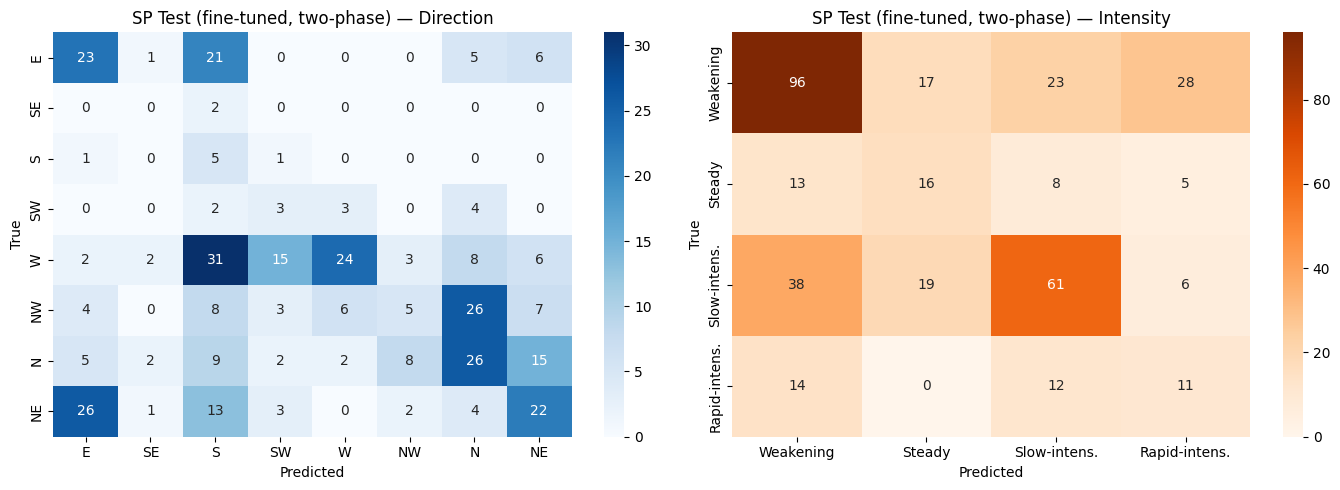

In [26]:
fig = plot_confusion_matrices(sp_ft_test_metrics,
                              f"SP Test (fine-tuned, {best_ft_strategy})")
fig.savefig(PROJECT_ROOT / "figures" / "resnet_sp_finetuned_confusion.png", dpi=150,
            bbox_inches="tight")
plt.show()

In [27]:
# ── Three-way comparison ──
print("\n" + "=" * 75)
print(" Cross-Basin Transfer Summary")
print("=" * 75)
print(f"{'Setting':<30s} {'Dir Acc':>8s} {'Dir F1':>8s} "
      f"{'Int Acc':>8s} {'Int F1':>8s}")
print("-" * 65)

for name, m in [
    ("WP Val (in-basin)",          wp_val_metrics),
    ("SP Test (zero-shot)",        sp_zs_metrics),
    (f"SP Test (FT {best_ft_strategy})", sp_ft_test_metrics),
]:
    print(f"{name:<30s} {m['dir_acc']:>8.3f} {m['dir_f1']:>8.3f} "
          f"{m['int_acc']:>8.3f} {m['int_f1']:>8.3f}")


 Cross-Basin Transfer Summary
Setting                         Dir Acc   Dir F1  Int Acc   Int F1
-----------------------------------------------------------------
WP Val (in-basin)                 0.512    0.404    0.549    0.463
SP Test (zero-shot)               0.272    0.212    0.384    0.319
SP Test (FT two-phase)            0.294    0.234    0.501    0.430


## Section 7: Analysis

ResNet-specific analysis: **Grad-CAM** visualisation of which spatial regions the model attends to, and **layer activation statistics** showing how feature representations evolve through the network.

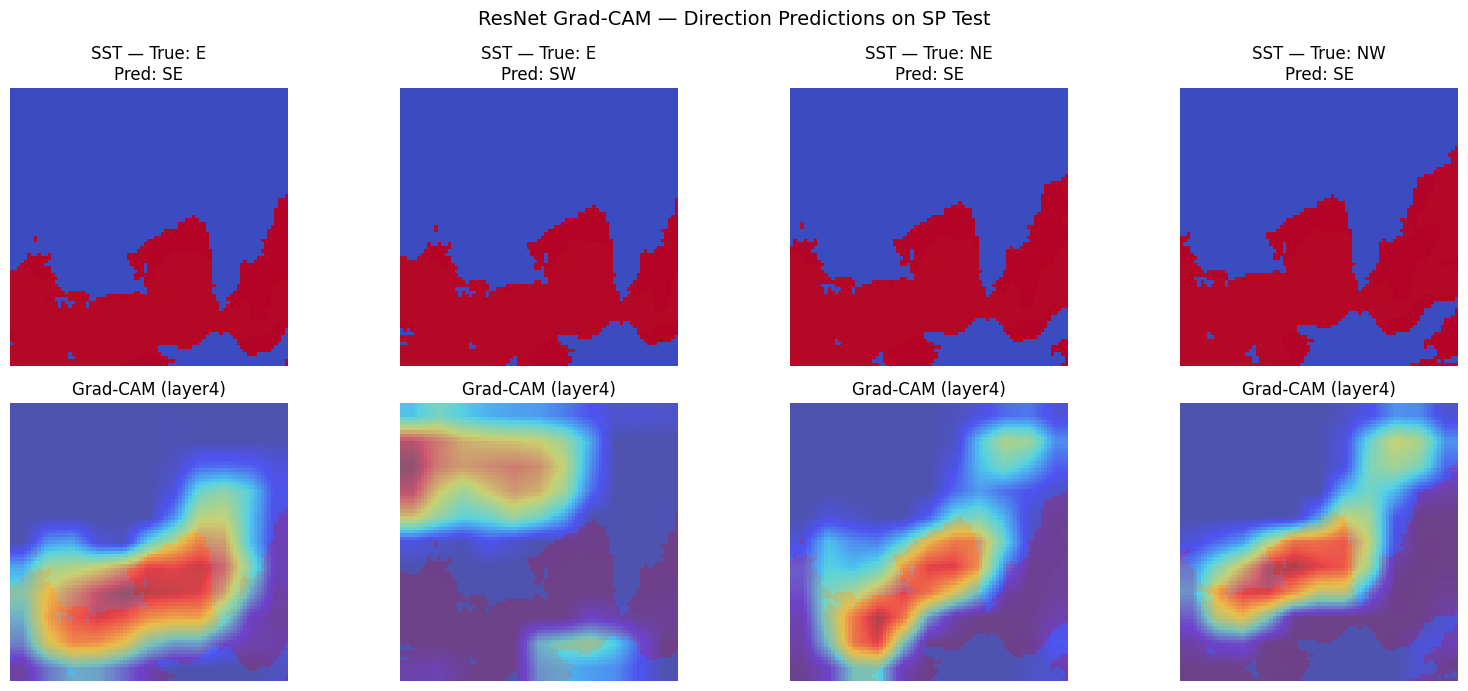

In [28]:
# Reload WP-trained model for analysis
model = ResNetClassifier(
    resnet_size=RESNET_SIZE, in_channels=IN_CHANNELS,
    n_dir_classes=N_DIR_CLASSES, n_int_classes=N_INT_CLASSES,
    env_dim=40, d1d_dim=4, use_env=USE_ENV, use_1d=USE_1D,
    head_dim=BEST_HEAD_DIM, dropout=BEST_DROPOUT,
).to(DEVICE)
model.load_state_dict(best_model_state)

# ── Grad-CAM on ResNet layer4 ──
# Visualise which spatial regions layer4 attends to for direction prediction

model.eval()

# Get a batch of SP test samples
sample_batch = next(iter(loaders["sp_test"]))
grid, env, d1d, dir_lbl, int_lbl = [x.to(DEVICE) for x in sample_batch]

# Hook to capture layer4 activations and gradients
activations = {}
gradients = {}

def forward_hook(module, input, output):
    activations["layer4"] = output.detach()

def backward_hook(module, grad_input, grad_output):
    gradients["layer4"] = grad_output[0].detach()

fh = model.layer4.register_forward_hook(forward_hook)
bh = model.layer4.register_full_backward_hook(backward_hook)

# Forward + backward for direction prediction
model.zero_grad()
dir_logits, _ = model(grid, env, d1d)
# Use the predicted class for Grad-CAM
pred_classes = dir_logits.argmax(dim=1)
one_hot = F.one_hot(pred_classes, N_DIR_CLASSES).float()
(dir_logits * one_hot).sum().backward()

fh.remove()
bh.remove()

# Compute Grad-CAM: global average pool gradients → weight activations
weights = gradients["layer4"].mean(dim=(-2, -1), keepdim=True)  # (B, C, 1, 1)
cam = (weights * activations["layer4"]).sum(dim=1)  # (B, H, W)
cam = F.relu(cam)  # only positive contributions
# Normalise per sample
cam_min = cam.flatten(1).min(dim=1).values[:, None, None]
cam_max = cam.flatten(1).max(dim=1).values[:, None, None]
cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)

# Upsample to input resolution
cam_up = F.interpolate(cam.unsqueeze(1), size=(81, 81),
                       mode="bilinear", align_corners=False).squeeze(1)

# Plot 4 samples
n_show = min(4, grid.shape[0])
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 7))

for i in range(n_show):
    # SST channel as background
    sst = grid[i, 0].cpu().numpy()
    axes[0, i].imshow(sst, cmap="coolwarm", origin="lower")
    axes[0, i].set_title(f"SST — True: {DIR_LABELS[dir_lbl[i]]}\n"
                         f"Pred: {DIR_LABELS[pred_classes[i]]}")
    axes[0, i].axis("off")

    # Grad-CAM overlay
    axes[1, i].imshow(sst, cmap="coolwarm", origin="lower", alpha=0.5)
    axes[1, i].imshow(cam_up[i].cpu().numpy(), cmap="jet", origin="lower",
                      alpha=0.5, vmin=0, vmax=1)
    axes[1, i].set_title("Grad-CAM (layer4)")
    axes[1, i].axis("off")

plt.suptitle("ResNet Grad-CAM — Direction Predictions on SP Test", fontsize=14)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "resnet_gradcam.png", dpi=150,
            bbox_inches="tight")
plt.show()

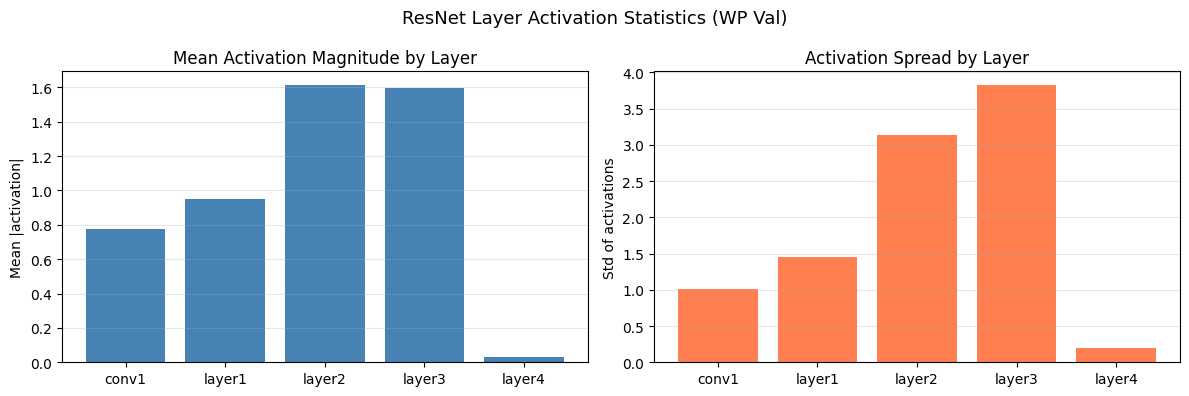

  conv1   : mean |act| = 0.7741, std = 1.0064
  layer1  : mean |act| = 0.9502, std = 1.4588
  layer2  : mean |act| = 1.6120, std = 3.1335
  layer3  : mean |act| = 1.5970, std = 3.8231
  layer4  : mean |act| = 0.0285, std = 0.1948


In [29]:
# ── Layer activation statistics ──
# Track mean activation magnitude through each ResNet layer group

model.eval()
layer_stats = {name: {"means": [], "stds": []} for name in
               ["conv1", "layer1", "layer2", "layer3", "layer4"]}

hooks = []

def make_stats_hook(name):
    def hook(module, input, output):
        layer_stats[name]["means"].append(output.detach().abs().mean().item())
        layer_stats[name]["stds"].append(output.detach().std().item())
    return hook

hooks.append(model.conv1.register_forward_hook(make_stats_hook("conv1")))
hooks.append(model.layer1.register_forward_hook(make_stats_hook("layer1")))
hooks.append(model.layer2.register_forward_hook(make_stats_hook("layer2")))
hooks.append(model.layer3.register_forward_hook(make_stats_hook("layer3")))
hooks.append(model.layer4.register_forward_hook(make_stats_hook("layer4")))

# Run through WP val set
with torch.no_grad():
    for grid, env, d1d, _, _ in loaders["wp_val"]:
        model(grid.to(DEVICE), env.to(DEVICE), d1d.to(DEVICE))

for h in hooks:
    h.remove()

# Plot
layer_names = list(layer_stats.keys())
means = [np.mean(layer_stats[n]["means"]) for n in layer_names]
stds  = [np.mean(layer_stats[n]["stds"]) for n in layer_names]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(layer_names, means, color="steelblue")
axes[0].set_ylabel("Mean |activation|")
axes[0].set_title("Mean Activation Magnitude by Layer")
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].bar(layer_names, stds, color="coral")
axes[1].set_ylabel("Std of activations")
axes[1].set_title("Activation Spread by Layer")
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("ResNet Layer Activation Statistics (WP Val)", fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "resnet_layer_activations.png", dpi=150,
            bbox_inches="tight")
plt.show()

for n in layer_names:
    print(f"  {n:8s}: mean |act| = {np.mean(layer_stats[n]['means']):.4f}, "
          f"std = {np.mean(layer_stats[n]['stds']):.4f}")

Storm: OMA (43 timesteps)


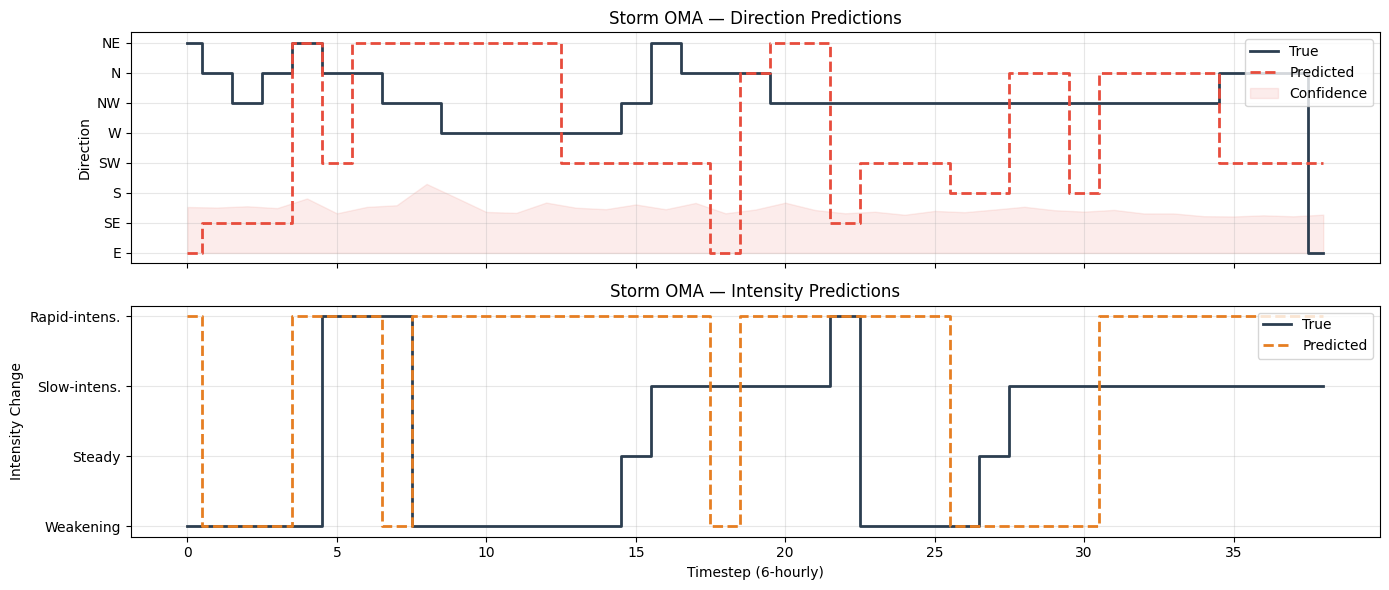

In [30]:
# ── Per-storm prediction timeline (sample SP storm) ──
# Pick one storm from sp_test and show predictions over time
sp_grids  = raw["sp_test"]["grids"]
sp_env    = raw["sp_test"]["env"]
sp_d1d    = raw["sp_test"]["data1d"]
sp_labels = raw["sp_test"]["labels"]

# Pick the longest storm
storm_id = max(sp_grids, key=lambda k: sp_grids[k].shape[0])
n_ts = sp_grids[storm_id].shape[0]
print(f"Storm: {storm_id} ({n_ts} timesteps)")

# Run predictions for each timestep
model.eval()
dir_preds, int_preds = [], []
dir_confs, int_confs = [], []
dir_true_list, int_true_list = [], []

with torch.no_grad():
    for t in range(n_ts):
        d_lbl = sp_labels[storm_id]["direction_reflected"][t].item()
        i_lbl = sp_labels[storm_id]["intensity"][t].item()
        if d_lbl == -1 or i_lbl == -1:
            continue

        # Grids are already normalised by preprocessing
        g = sp_grids[storm_id][t].unsqueeze(0).to(DEVICE)
        e = sp_env[storm_id][t].unsqueeze(0).to(DEVICE)
        d = sp_d1d[storm_id][t].unsqueeze(0).to(DEVICE)

        d_logits, i_logits = model(g, e, d)
        d_probs = F.softmax(d_logits, dim=1)
        i_probs = F.softmax(i_logits, dim=1)

        dir_preds.append(d_logits.argmax(1).item())
        int_preds.append(i_logits.argmax(1).item())
        dir_confs.append(d_probs.max().item())
        int_confs.append(i_probs.max().item())
        dir_true_list.append(d_lbl)
        int_true_list.append(i_lbl)

timesteps = np.arange(len(dir_preds))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Direction
axes[0].step(timesteps, dir_true_list, where="mid", label="True",
             color="#2c3e50", linewidth=2)
axes[0].step(timesteps, dir_preds, where="mid", label="Predicted",
             color="#e74c3c", linewidth=2, linestyle="--")
axes[0].fill_between(timesteps, 0, [c * 7 for c in dir_confs],
                     alpha=0.1, color="#e74c3c", label="Confidence")
axes[0].set_yticks(range(8))
axes[0].set_yticklabels(DIR_LABELS)
axes[0].set_ylabel("Direction")
axes[0].set_title(f"Storm {storm_id} — Direction Predictions")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)

# Intensity
axes[1].step(timesteps, int_true_list, where="mid", label="True",
             color="#2c3e50", linewidth=2)
axes[1].step(timesteps, int_preds, where="mid", label="Predicted",
             color="#e67e22", linewidth=2, linestyle="--")
axes[1].set_yticks(range(4))
axes[1].set_yticklabels(INTE_LABELS)
axes[1].set_xlabel("Timestep (6-hourly)")
axes[1].set_ylabel("Intensity Change")
axes[1].set_title(f"Storm {storm_id} — Intensity Predictions")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "resnet_storm_timeline.png", dpi=150,
            bbox_inches="tight")
plt.show()

In [31]:
# ── Final summary ──
print("\n" + "=" * 80)
print(" ResNet Cross-Basin Transfer — Final Results")
print("=" * 80)
print(f"\nModel: ResNetClassifier ({RESNET_SIZE})")
print(f"  Head dim: {BEST_HEAD_DIM}, Dropout: {BEST_DROPOUT}")
print(f"  Parameters: {n_params:,}")
print(f"  Multimodal: grid (15ch) + env ({40 if USE_ENV else 0}d) "
      f"+ 1D ({4 if USE_1D else 0}d)")
print(f"  Optimizer: AdamW, LR: {LR}")

print(f"\n{'Setting':<35s} {'Dir Acc':>8s} {'Dir F1':>8s} "
      f"{'Int Acc':>8s} {'Int F1':>8s}")
print("-" * 70)
for name, m in [
    ("WP Validation (in-basin)",          wp_val_metrics),
    ("SP Test (zero-shot)",               sp_zs_metrics),
    (f"SP Test (fine-tuned, {best_ft_strategy})", sp_ft_test_metrics),
]:
    print(f"{name:<35s} {m['dir_acc']:>8.3f} {m['dir_f1']:>8.3f} "
          f"{m['int_acc']:>8.3f} {m['int_f1']:>8.3f}")

# Transfer efficiency
zs_gap_dir = sp_zs_metrics["dir_acc"] - wp_val_metrics["dir_acc"]
ft_recovery = (sp_ft_test_metrics["dir_acc"] - sp_zs_metrics["dir_acc"])
print(f"\nZero-shot transfer gap (direction):  {zs_gap_dir:+.3f}")
print(f"Fine-tuning recovery (direction):     {ft_recovery:+.3f}")

# Save model
save_path = PROJECT_ROOT / "experiments" / "resnet_best_wp.pt"
torch.save(best_model_state, save_path)
print(f"\nBest WP model saved to: {save_path}")

ft_save_path = PROJECT_ROOT / "experiments" / "resnet_best_ft.pt"
torch.save(best_ft_model.state_dict(), ft_save_path)
print(f"Best fine-tuned model saved to: {ft_save_path}")


 ResNet Cross-Basin Transfer — Final Results

Model: ResNetClassifier (resnet152)
  Head dim: 128, Dropout: 0.25
  Parameters: 58,696,140
  Multimodal: grid (15ch) + env (40d) + 1D (4d)
  Optimizer: AdamW, LR: 0.0005

Setting                              Dir Acc   Dir F1  Int Acc   Int F1
----------------------------------------------------------------------
WP Validation (in-basin)               0.512    0.404    0.549    0.463
SP Test (zero-shot)                    0.272    0.212    0.384    0.319
SP Test (fine-tuned, two-phase)        0.294    0.234    0.501    0.430

Zero-shot transfer gap (direction):  -0.240
Fine-tuning recovery (direction):     +0.022

Best WP model saved to: /root/climate-change-group-project/experiments/resnet_best_wp.pt


Best fine-tuned model saved to: /root/climate-change-group-project/experiments/resnet_best_ft.pt
